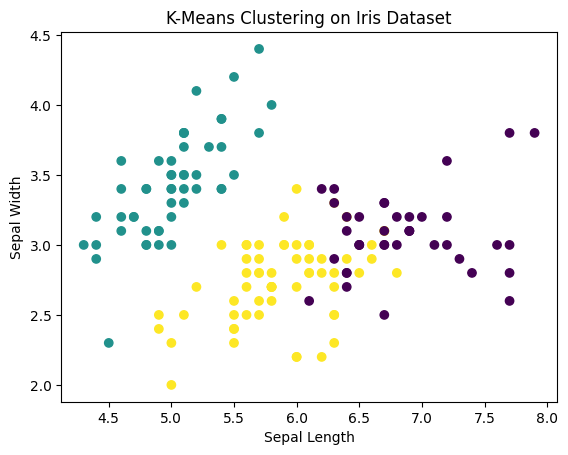

In [ ]:
# Step 1: Import libraries
import seaborn as sns
import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Step 2: Load dataset from seaborn
iris = sns.load_dataset('iris')

# Step 3: Select features (drop species since it's the label)
X = iris.drop(columns=['species'])

# Step 4: Apply KMeans
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X)

# Step 5: Add cluster labels to dataset
iris['cluster'] = kmeans.labels_

# Step 6: Visualize (using first two features)
plt.scatter(iris['sepal_length'], iris['sepal_width'], c=iris['cluster'])
plt.xlabel('Sepal Length')
plt.ylabel('Sepal Width')
plt.title('K-Means Clustering on Iris Dataset')
plt.show()

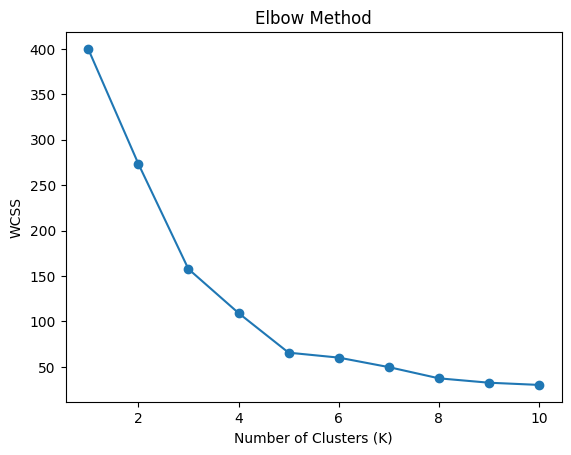

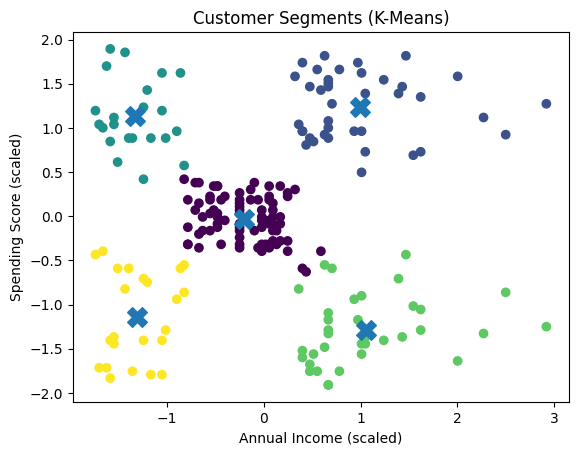

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Load dataset
data = pd.read_csv('Mall_Customers.csv')

# Select features (best for visualization)
X = data[['Annual Income (k$)', 'Spending Score (1-100)']]

# Scale data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ----------- ELBOW METHOD -----------
wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Plot Elbow Graph
plt.figure()
plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

# ----------- FINAL KMEANS (K=5) -----------
kmeans = KMeans(n_clusters=5, random_state=42)
labels = kmeans.fit_predict(X_scaled)

# ----------- CLUSTER VISUALIZATION -----------
plt.figure()
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels)

# Plot centroids
centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], marker='X', s=200)

plt.xlabel("Annual Income (scaled)")
plt.ylabel("Spending Score (scaled)")
plt.title("Customer Segments (K-Means)")
plt.show()